# Is Hier-COS inference itself the main advantage?

This notebook performs an inference-only, paired comparison on existing checkpoints. No model is retrained.

- **H-CAST and HRN:** native inference versus post-hoc identity-frame Hier-COS distance inference.
- **Hier-COS:** native distance inference versus direct global node-softmax inference.

The key quantity is the within-checkpoint **distance gain**. Positive always means that distance inference is better, including for lower-is-better AHD and TICE. Absolute cross-model scores are secondary because architectures and training objectives differ. Every completed seed is evaluated separately; its YAML stays in that seed's run directory, and tables/plots report mean ± sample standard deviation with the seed count.

## Experimental cautions

1. H-CAST/HRN logits were not trained as Hier-COS coordinates; identity-frame decoding is a post-hoc assumption.
2. The available best checkpoints were selected using each model's native validation inference. This can favor native inference.
3. Top-down and independent rows must use their corresponding best checkpoints. This notebook preserves that rule.
4. Unequal seed coverage must be reported. A one-seed sign is suggestive, not robust evidence.
5. Treat this test-set analysis as a pre-specified ablation. Do not tune normalization or score variants repeatedly on test data.

In [22]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'evaluation').is_dir():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'evaluation').is_dir(), 'Run this notebook from the repository or notebooks directory.'

NOTEBOOK_UTILS = str(REPO_ROOT / 'notebooks')
if NOTEBOOK_UTILS not in sys.path:
    sys.path.insert(0, NOTEBOOK_UTILS)
from multiseed_utils import discover_seed_dirs, sample_stats

OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
DATASETS = ('cifar100', 'cub200', 'aircraft')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cpu':
    print('CUDA is unavailable; inference will run on CPU and may be slow.')
RUN_EVALUATION = True  # The next execution cell runs the Python checkpoint evaluator.
OVERWRITE = False

BASELINE_ROOTS = {
    'cifar100': {
        'hcast': OUTPUTS_ROOT / 'hcast_cifar100',
        'hrn': OUTPUTS_ROOT / 'hrn_cifar100',
        'hiercos': OUTPUTS_ROOT / 'hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf',
    },
    'cub200': {
        'hcast': OUTPUTS_ROOT / 'hcast_cub200',
        'hrn': OUTPUTS_ROOT / 'hrn_cub200',
        'hiercos': OUTPUTS_ROOT / 'hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf',
    },
    'aircraft': {
        'hcast': OUTPUTS_ROOT / 'hcast_aircraft',
        'hrn': OUTPUTS_ROOT / 'hrn_aircraft',
        'hiercos': OUTPUTS_ROOT / 'hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf',
    },
}

BASELINE_ROOTS

{'cifar100': {'hcast': PosixPath('/scratch/g.saggini1/outputs/hcast_cifar100'),
  'hrn': PosixPath('/scratch/g.saggini1/outputs/hrn_cifar100'),
  'hiercos': PosixPath('/scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf')},
 'cub200': {'hcast': PosixPath('/scratch/g.saggini1/outputs/hcast_cub200'),
  'hrn': PosixPath('/scratch/g.saggini1/outputs/hrn_cub200'),
  'hiercos': PosixPath('/scratch/g.saggini1/outputs/hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf')},
 'aircraft': {'hcast': PosixPath('/scratch/g.saggini1/outputs/hcast_aircraft'),
  'hrn': PosixPath('/scratch/g.saggini1/outputs/hrn_aircraft'),
  'hiercos': PosixPath('/scratch/g.saggini1/outputs/hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf')}}

In [23]:
def completed_seed_dirs(root: Path):
    seed_dirs = discover_seed_dirs(root, require_log=False, require_config=True)
    candidates = seed_dirs or ([root] if root.is_dir() else [])
    required = ('config_resolved.yaml', 'best_topdown.pt', 'best_independent.pt')
    return [path for path in candidates if all((path / name).is_file() for name in required)]

run_dirs = {
    dataset: {model: completed_seed_dirs(root) for model, root in BASELINE_ROOTS[dataset].items()}
    for dataset in DATASETS
}
coverage = pd.DataFrame(
    [
        {'dataset': dataset, 'model': model, 'runs': len(paths), 'paths': [str(path) for path in paths]}
        for dataset, model_runs in run_dirs.items()
        for model, paths in model_runs.items()
    ]
)
display(coverage)
missing_baselines = coverage.loc[coverage['runs'].eq(0), ['dataset', 'model']]
if not missing_baselines.empty:
    print('Missing completed baselines:')
    display(missing_baselines)
    print('Edit BASELINE_ROOTS or finish those runs before making a three-model claim.')

,dataset,model,runs,paths
0,cifar100,hcast,1,[/scratch/g.saggini1/outputs/hcast_cifar100/se...
1,cifar100,hrn,0,[]
2,cifar100,hiercos,3,[/scratch/g.saggini1/outputs/hiercos_cifar100_...
3,cub200,hcast,1,[/scratch/g.saggini1/outputs/hcast_cub200/seed_0]
4,cub200,hrn,1,[/scratch/g.saggini1/outputs/hrn_cub200/seed_0]
5,cub200,hiercos,3,[/scratch/g.saggini1/outputs/hiercos_cub200_gl...
6,aircraft,hcast,1,[/scratch/g.saggini1/outputs/hcast_aircraft/se...
7,aircraft,hrn,1,[/scratch/g.saggini1/outputs/hrn_aircraft/seed_0]
8,aircraft,hiercos,3,[/scratch/g.saggini1/outputs/hiercos_aircraft_...


Missing completed baselines:


,dataset,model
1,cifar100,hrn


Edit BASELINE_ROOTS or finish those runs before making a three-model claim.


In [24]:
result_files = []
for dataset, model_runs in run_dirs.items():
    for model, paths in model_runs.items():
        for run_dir in paths:
            output_path = run_dir / 'posthoc_inference_test_metrics.yaml'
            result_files.append(output_path)
            if not RUN_EVALUATION:
                continue
            if output_path.exists() and not OVERWRITE:
                print('[reuse]', output_path)
                continue
            command = [
                sys.executable, '-m', 'evaluation.evaluate_checkpoints',
                '--run-dir', str(run_dir),
                '--inference-mode', 'both',
                '--checkpoint-mode', 'both',
                '--device', DEVICE,
            ]
            if OVERWRITE:
                command.append('--overwrite')
            print('[run]', ' '.join(command))
            subprocess.run(command, cwd=REPO_ROOT, check=True)

available_result_files = [path for path in result_files if path.is_file()]
print(f'Available result files: {len(available_result_files)}/{len(result_files)}')
if not RUN_EVALUATION and not available_result_files:
    print('Set RUN_EVALUATION=True and run this cell to generate results.')

[reuse] /scratch/g.saggini1/outputs/hcast_cifar100/seed_0/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf/seed_0/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf/seed_1/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf/seed_2/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hcast_cub200/seed_0/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hrn_cub200/seed_0/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf/seed_0/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf/seed_1/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hiercos_cub200_gl

In [25]:
records = []
for result_path in available_result_files:
    payload = yaml.safe_load(result_path.read_text())
    model = payload['model']
    seed = int(payload['seed'])
    for checkpoint_mode, checkpoint_payload in payload['checkpoints'].items():
        for inference_mode, metrics in checkpoint_payload['inference'].items():
            for metric, value in metrics.items():
                # Keep only the decoder matched to the validation-selected checkpoint.
                if metric.startswith(('fpa_', 'tice_', 'ahd_', 'weighted_ap_')) and not metric.endswith(checkpoint_mode):
                    continue
                if metric.startswith('acc_level_') and f'acc_level_{checkpoint_mode}_' not in metric:
                    continue
                records.append({
                    'dataset': payload['dataset'],
                    'model': model,
                    'seed': seed,
                    'checkpoint_mode': checkpoint_mode,
                    'inference': inference_mode,
                    'metric': metric,
                    'value': float(value),
                })

results_long = pd.DataFrame(records)
if results_long.empty:
    print('No result rows loaded yet.')
else:
    display(results_long.head())

,dataset,model,seed,checkpoint_mode,inference,metric,value
0,cifar-100,hcast,0,topdown,normal,acc_level_topdown_1,0.8520
1,cifar-100,hcast,0,topdown,normal,ahd_topdown,0.4869
2,cifar-100,hcast,0,topdown,normal,acc_level_topdown_0,0.9092
3,cifar-100,hcast,0,topdown,normal,fpa_topdown,0.7519
4,cifar-100,hcast,0,topdown,normal,tice_topdown,0.0000


In [26]:
DISTANCE_MODE = {'hcast': 'hiercos', 'hrn': 'hiercos', 'hiercos': 'normal'}
REFERENCE_MODE = {'hcast': 'normal', 'hrn': 'normal', 'hiercos': 'node_softmax'}
LOWER_IS_BETTER_PREFIXES = ('ahd_', 'tice_')

paired_rows = []
if not results_long.empty:
    index_cols = ['dataset', 'model', 'seed', 'checkpoint_mode', 'metric']
    wide = results_long.pivot_table(index=index_cols, columns='inference', values='value', aggfunc='first').reset_index()
    for row in wide.to_dict('records'):
        distance_mode = DISTANCE_MODE[row['model']]
        reference_mode = REFERENCE_MODE[row['model']]
        if distance_mode not in row or reference_mode not in row:
            continue
        distance_value = row[distance_mode]
        reference_value = row[reference_mode]
        if pd.isna(distance_value) or pd.isna(reference_value):
            continue
        lower_is_better = row['metric'].startswith(LOWER_IS_BETTER_PREFIXES)
        gain = reference_value - distance_value if lower_is_better else distance_value - reference_value
        paired_rows.append({
            **{key: row[key] for key in index_cols},
            'distance_inference': distance_mode,
            'reference_inference': reference_mode,
            'distance_value': distance_value,
            'reference_value': reference_value,
            'distance_gain': gain,
        })

paired = pd.DataFrame(paired_rows)
if paired.empty:
    print('No paired comparisons available.')
else:
    paired['distance_gain_display'] = paired.apply(
        lambda row: row['distance_gain'] if row['metric'].startswith('ahd_') else 100.0 * row['distance_gain'],
        axis=1,
    )
    display(paired.sort_values(['checkpoint_mode', 'metric', 'model', 'seed']))

,dataset,model,seed,checkpoint_mode,metric,distance_inference,reference_inference,distance_value,reference_value,distance_gain,distance_gain_display
0,cifar-100,hcast,0,independent,acc_level_independent_0,hiercos,normal,0.907800,0.909200,-0.001400,-0.140000
56,cub-200-2011,hcast,0,independent,acc_level_independent_0,hiercos,normal,0.681912,0.983776,-0.301864,-30.186400
126,fgvc-aircraft,hcast,0,independent,acc_level_independent_0,hiercos,normal,0.606661,0.097210,0.509451,50.945095
14,cifar-100,hiercos,0,independent,acc_level_independent_0,normal,node_softmax,0.912800,0.913200,-0.000400,-0.040000
70,cub-200-2011,hiercos,0,independent,acc_level_independent_0,normal,node_softmax,0.967898,0.966517,0.001381,0.138074
...,...,...,...,...,...,...,...,...,...,...,...
55,cifar-100,hiercos,2,topdown,weighted_ap_topdown,normal,node_softmax,0.801009,0.801434,-0.000425,-0.042500
111,cub-200-2011,hiercos,2,topdown,weighted_ap_topdown,normal,node_softmax,0.798728,0.797940,0.000787,0.078732
181,fgvc-aircraft,hiercos,2,topdown,weighted_ap_topdown,normal,node_softmax,0.858836,0.858431,0.000405,0.040504
125,cub-200-2011,hrn,0,topdown,weighted_ap_topdown,hiercos,normal,0.525134,0.866219,-0.341085,-34.108509


Absolute inference results (mean, sample standard deviation, seed count):


,dataset,model,checkpoint_mode,inference,metric,mean_value,std_value,seeds
0,cifar-100,hcast,independent,hiercos,acc_level_independent_0,90.780000,NaN,1
1,cifar-100,hcast,independent,hiercos,acc_level_independent_1,85.550000,NaN,1
2,cifar-100,hcast,independent,hiercos,acc_level_independent_2,75.460000,NaN,1
3,cifar-100,hcast,independent,hiercos,ahd_independent,0.512000,NaN,1
4,cifar-100,hcast,independent,hiercos,fpa_independent,73.920000,NaN,1
...,...,...,...,...,...,...,...,...
219,fgvc-aircraft,hrn,topdown,normal,acc_level_topdown_2,6.630663,NaN,1
220,fgvc-aircraft,hrn,topdown,normal,ahd_topdown,2.780378,NaN,1
221,fgvc-aircraft,hrn,topdown,normal,fpa_topdown,6.630663,NaN,1
222,fgvc-aircraft,hrn,topdown,normal,tice_topdown,0.000000,NaN,1


Paired distance-inference gains (mean, sample standard deviation, seed count):


,dataset,model,checkpoint_mode,metric,mean_distance_gain,std_distance_gain,seeds
0,cifar-100,hcast,independent,acc_level_independent_0,-0.140000,NaN,1
1,cifar-100,hcast,independent,acc_level_independent_1,0.130000,NaN,1
2,cifar-100,hcast,independent,acc_level_independent_2,-0.250000,NaN,1
3,cifar-100,hcast,independent,ahd_independent,-0.003300,NaN,1
4,cifar-100,hcast,independent,fpa_independent,0.580000,NaN,1
...,...,...,...,...,...,...,...
107,fgvc-aircraft,hrn,topdown,acc_level_topdown_2,20.732073,NaN,1
108,fgvc-aircraft,hrn,topdown,ahd_topdown,0.722472,NaN,1
109,fgvc-aircraft,hrn,topdown,fpa_topdown,20.732073,NaN,1
110,fgvc-aircraft,hrn,topdown,tice_topdown,0.000000,NaN,1


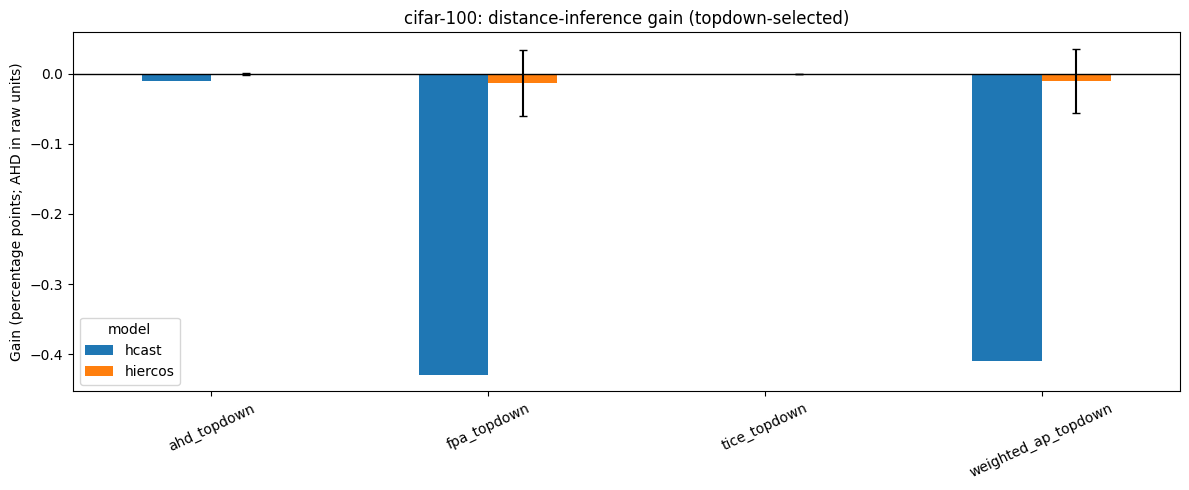

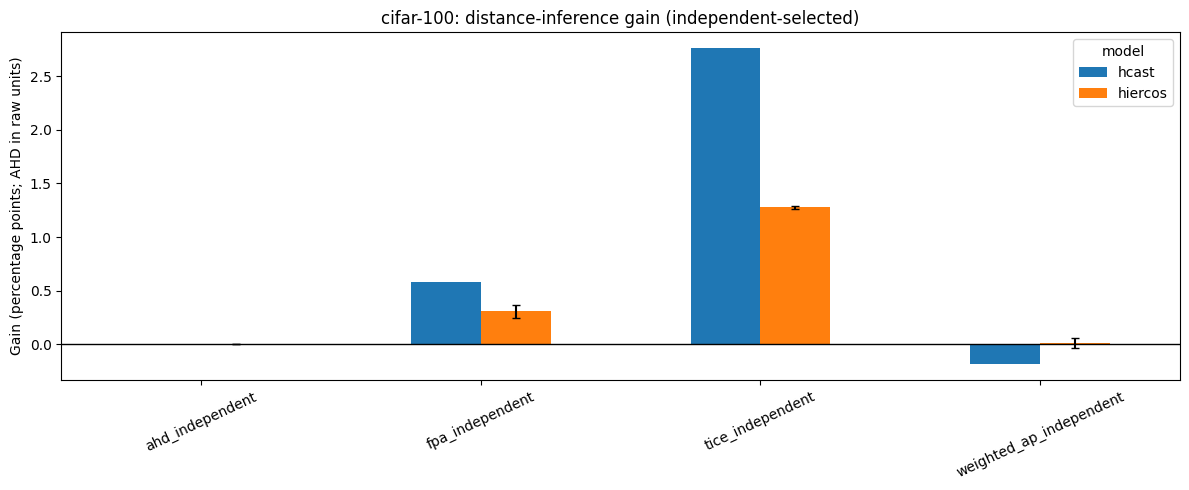

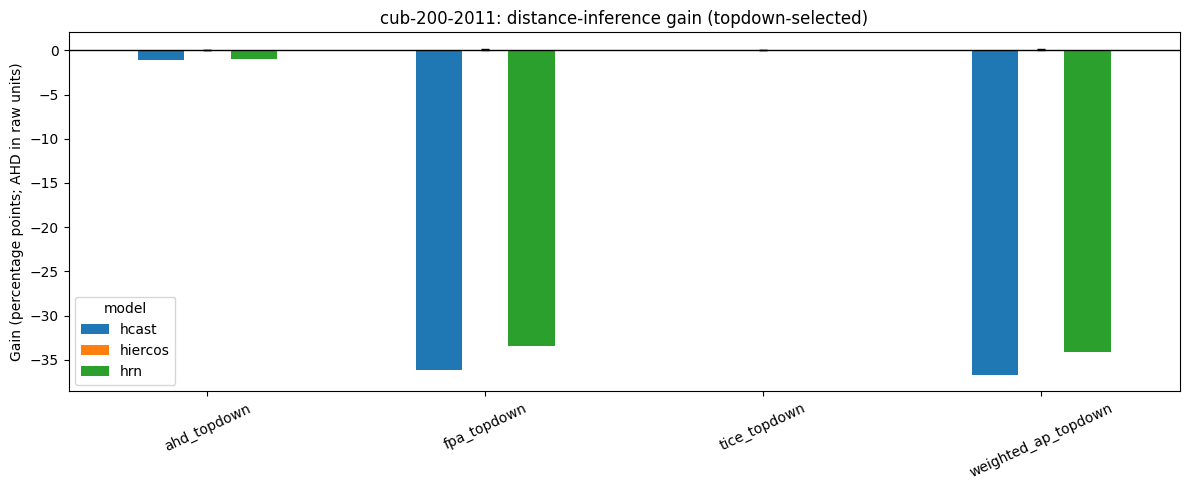

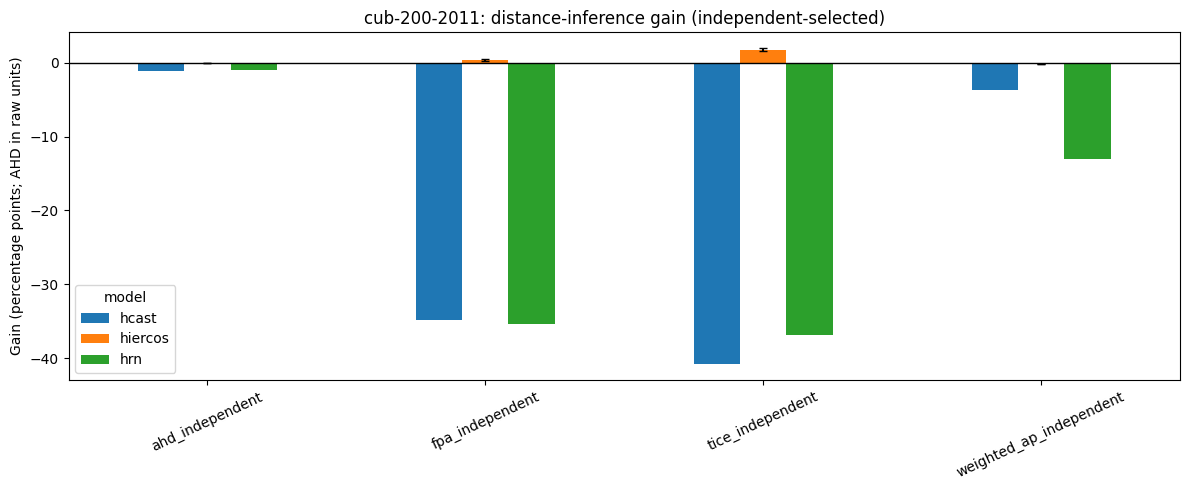

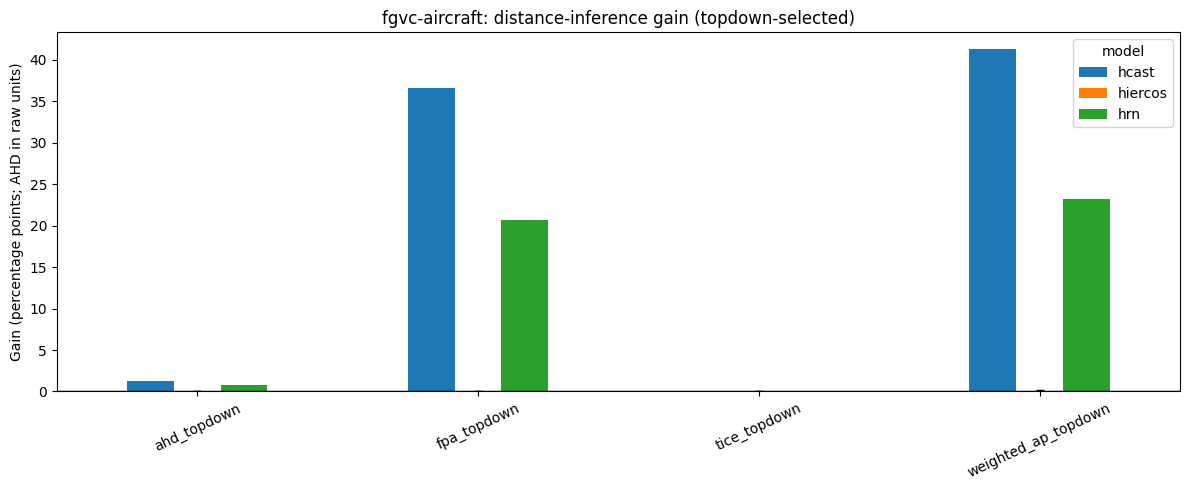

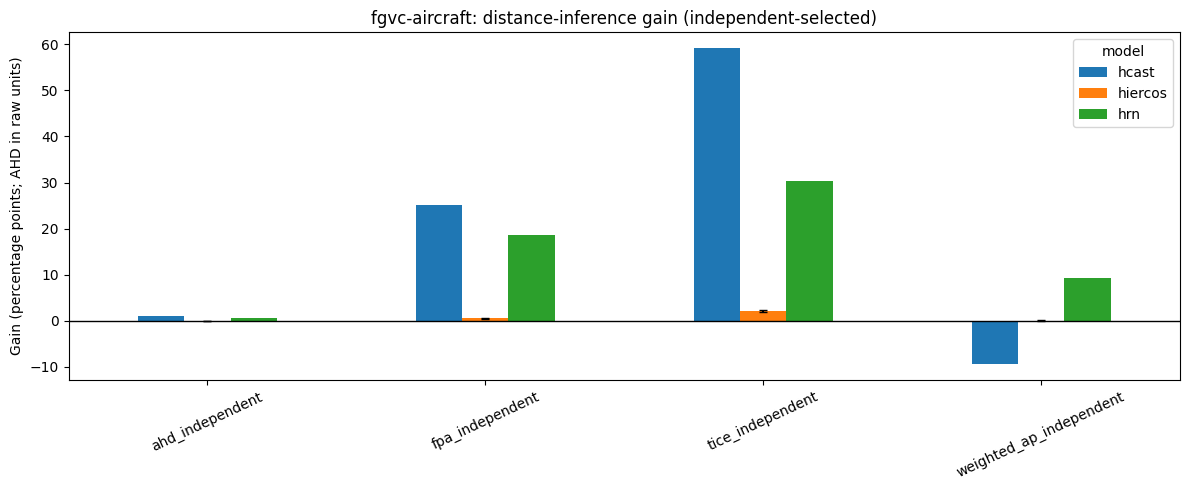

In [27]:
def summarize_samples(frame, group_columns, value_column, mean_column, std_column):
    rows = []
    for keys, group in frame.groupby(group_columns, dropna=False):
        keys = keys if isinstance(keys, tuple) else (keys,)
        mean, std, count = sample_stats(group[value_column].tolist())
        rows.append({
            **dict(zip(group_columns, keys)),
            mean_column: mean,
            std_column: std,
            'seeds': count,
        })
    return pd.DataFrame(rows)

if not results_long.empty:
    results_long['value_display'] = results_long.apply(
        lambda row: row['value'] if row['metric'].startswith('ahd_') else 100.0 * row['value'],
        axis=1,
    )
    absolute_summary = summarize_samples(
        results_long,
        ['dataset', 'model', 'checkpoint_mode', 'inference', 'metric'],
        'value_display',
        'mean_value',
        'std_value',
    )
    print('Absolute inference results (mean, sample standard deviation, seed count):')
    display(absolute_summary)

if not paired.empty:
    summary = summarize_samples(
        paired,
        ['dataset', 'model', 'checkpoint_mode', 'metric'],
        'distance_gain_display',
        'mean_distance_gain',
        'std_distance_gain',
    )
    print('Paired distance-inference gains (mean, sample standard deviation, seed count):')
    display(summary)

    core = summary[summary['metric'].str.startswith(('fpa_', 'tice_', 'ahd_', 'weighted_ap_'))].copy()
    for dataset in sorted(core['dataset'].unique()):
        for checkpoint_mode in ('topdown', 'independent'):
            plot_data = core[(core['dataset'] == dataset) & (core['checkpoint_mode'] == checkpoint_mode)]
            if plot_data.empty:
                continue
            mean_pivot = plot_data.pivot(index='metric', columns='model', values='mean_distance_gain')
            std_pivot = (
                plot_data.pivot(index='metric', columns='model', values='std_distance_gain')
                .reindex(index=mean_pivot.index, columns=mean_pivot.columns)
            )
            ax = mean_pivot.plot(kind='bar', yerr=std_pivot, capsize=3, figsize=(12, 5), rot=25)
            ax.axhline(0.0, color='black', linewidth=1)
            ax.set_title(f'{dataset}: distance-inference gain ({checkpoint_mode}-selected)')
            ax.set_ylabel('Gain (percentage points; AHD in raw units)')
            ax.set_xlabel('')
            plt.tight_layout()
            plt.show()

## Interpreting the hypothesis

Evidence is **consistent with inference being a transferable main advantage** only if both conditions hold:

1. Post-hoc distance inference gives positive paired gains for H-CAST and HRN, preferably across both decoder/checkpoint modes and multiple seeds.
2. Replacing Hier-COS distance inference with direct node-softmax inference gives a positive distance gain for native Hier-COS.

Alternative outcomes:

- If native Hier-COS benefits but H-CAST/HRN do not, the decoder likely depends on the Hier-COS-trained representation rather than transferring by itself.
- If H-CAST/HRN improve but native Hier-COS does not degrade under node-softmax inference, distance decoding is useful post hoc but does not explain Hier-COS's advantage.
- If gains vary strongly by dataset, decoder, or seed, report the dependence instead of claiming a general mechanism.

Do not infer causality from absolute model rankings alone. The paired within-checkpoint gains are the relevant evidence.